In [21]:
# Imports to enable plotting functionality
import numpy as np
import matplotlib.pyplot as plt
import bz2
import pickle
import _pickle as cPickle
import os 
from scipy.io import loadmat

## functions to enable loading of the pickle files

In [22]:
# Pickle a file and then compress it into a file with extension 
def compressed_pickle(title, data):
    with bz2.BZ2File(title + '.pbz2', 'w') as f: 
        cPickle.dump(data, f)

# Load any compressed pickle file
def decompress_pickle(file):
    data = bz2.BZ2File(file+'.pbz2', 'rb')
    data = cPickle.load(data)
    return data

def findData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        
    return currents,thresholds

def findInitData(electrode, dir_path):
    substring = str(electrode[0])+'_'+str(electrode[1])+'_'+str(electrode[2])
    matching_files = []
    for root,dirs,files in os.walk(dir_path):
        for file in files:
            if substring in file:
                matching_files.append(file)
    
    currents = []
    thresholds = []
    init_seg = []
    init_time = []

    for file in matching_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        currents.append(data[0])
        thresholds.append(data[1])
        init_seg.append(data[2])
        init_time.append(data[3])
        
    return currents,thresholds,init_seg,init_time

def truncate_lists(X, Y, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    return X_truncated, Y_truncated

def truncate_lists_init(X, Y, S, T, threshold):
    # Use list comprehension to filter out indices where Y >= threshold
    X_truncated = [x for x, y in zip(X, Y) if np.abs(y) >= threshold]
    S_truncated = [s for s, y in zip(S, Y) if np.abs(y) >= threshold]
    T_truncated = [t for t, y in zip(T, Y) if np.abs(y) >= threshold]
    Y_truncated = [y for y in Y if np.abs(y) >= threshold]
    
    return X_truncated, Y_truncated, S_truncated, T_truncated

## Repeat historgrams, but this time normalize spiking counts 

In [36]:
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/fig5_offAxonal_z/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/fig5_onAxonal_threshold/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/fig5_onAxonal_v2_threshold/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/radial_v2/fig5_onAxonal/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/radial_v2/fig5_onAxonal_v2/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/fig5_offAxonal_y30_June/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/planar/fig5_offAxonal/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/radial_v2/fig5_onAxonal_largeSpace/005Dt/'
# dir_path = '/Volumes/Scratch/Users/vilkhu/sim-data/multisite/fixed/triphasic/fig6_somatic_v2/005Dt/'


# dir_path = '/Volumes/Lab/Users/vilkhu/data-backup/multisite/fixed/triphasic/planar/fig5_offAxonal/005Dt/'
dir_path = '/Volumes/Lab/Users/vilkhu/data-backup/sim-data/triplet_somatic_rotations/60deg/'

# Output the electrodes files 
filename = dir_path+'electrodes.pkl'
data = decompress_pickle(filename)
print('Electrodes: ',data)

# Find data files in dir
data_files = []
for root,dirs,files in os.walk(dir_path):
    for file in files:
        if '_' in file:
            data_files.append(file)

# Next, extract data
i1 = []
i2 = []
i3 = []
spikes = []
init_segs = []
data = []
for file in data_files:
        filename = dir_path+str(file)
        data = decompress_pickle(filename[:-5])
        
        # Output substring before '_' in file
        curr1 = round(float(file.split('_')[0]),2)
        curr2 = round(float(file.split('_')[1]),2)
        curr3 = round(float(file.split('_')[2][:-9]),2)
        # if np.abs(curr1) < 3.1 and np.abs(curr2) < 3.1:
        i1.append(curr1)
        i2.append(curr2)
        i3.append(curr3)
        spikes.append(data[0])
        init_segs.append(data[1])

Electrodes:  [[10 -17.321 42]
 [12.01 16.16 42]
 [37.99 1.16 42]]


In [37]:
# unroll list of lists
init_segs_unroll = [item for sublist in init_segs for item in sublist]

In [38]:
# Make list of unique segments, these are the bins
bins = np.unique(init_segs_unroll)
print('List of unique segs:\n', bins)

List of unique segs:
 [0]


In [39]:
# make an empty list of zeros of same length as bins
counts = np.zeros(len(bins))
print(counts)

[0.]


In [40]:
print(init_segs)

[[0], [], [], [], [0], [], [], [], [0], [0], [0], [0], [0], [], [], [], [], [0], [], [0], [], [0], [0], [], [], [], [0], [], [], [], [], [], [], [0], [], [], [], [0], [], [], [0], [], [], [], [0], [], [], [0], [], [], [], [], [], [], [0], [0], [], [0], [], [0], [], [], [], [], [], [], [0], [], [], [0], [], [], [], [], [], [], [], [0], [], [0], [], [0], [0], [], [], [], [], [], [0], [], [], [], [], [], [], [0], [], [0], [0], [], [], [], [0], [0], [], [], [], [], [], [], [], [0], [], [], [0], [], [], [], [0], [], [], [], [0], [0], [], [], [], [], [], [0], [], [], [0], [], [], [0], [], [0], [0], [], [], [], [], [], [], [], [0], [], [0], [0], [0], [], [], [], [0], [], [], [], [0], [0], [], [], [], [], [0], [], [0], [], [], [], [0], [0], [], [0], [], [], [0], [0], [], [0], [], [0], [], [0], [], [], [], [], [], [0], [0], [], [], [0], [0], [0], [], [0], [0], [], [], [], [], [0], [0], [0], [], [0], [], [], [], [], [], [], [], [0], [], [0], [], [], [], [0], [], [], [], [], [], [], [], [], [], [

In [41]:
# Also calculate center of mass 
COM = []

# march through init_segs, adjusting spike count normalized by number of spiking segs
counts = np.zeros(len(bins))
for lst in init_segs:
    # If spiking
    if len(lst) > 0:
        COM.append(np.mean(lst))
        normalized_spike = 1/len(lst)
        for seg in lst:
           # Find index of seg in bins and normalized_spike to same counts idx 
           idx = np.argwhere(bins == seg)[0][0]
           counts[idx] += normalized_spike
    else:
        # COM.append(4.1)
        COM.append(169)
        print('something must be wrong')

something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must b


something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must be wrong
something must 

In [42]:
# march through init_segs, adjusting spike count normalized by number of spiking segs
counts = np.zeros(len(bins))
for lst in init_segs:
    # If spiking
    if len(lst) > 0:
        normalized_spike = 1/len(lst)
        for seg in lst:
           # Find index of seg in bins and normalized_spike to same counts idx 
           idx = np.argwhere(bins == seg)[0][0]
           counts[idx] += normalized_spike


In [43]:
print(len(i1))
print(len(COM))
print(len(COM))

8000
8000
8000


In [44]:
print(counts)

[2534.]


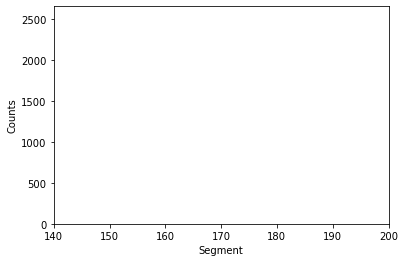

In [45]:
# Plot the histogram from pre-counted data
plt.bar(bins, counts, width=1, align='edge')

# Adding labels and title
plt.xlabel('Segment')
plt.ylabel('Counts')
# plt.xlim([130,210])
plt.xlim([140,200])
# plt.xlim([0,8])

# Show the plot
plt.show()

In [46]:
total_counts = sum(counts)
# total_counts = 2412.0
bin_width = bins[1] - bins[0]
normalized_counts = [count / (total_counts * bin_width) for count in counts]
# Plot the normalized histogram from pre-counted data
plt.bar(bins, normalized_counts, width=1, align='edge')

# Adding labels and title
plt.xlabel('Segment')
plt.ylabel('Probability Density')
# plt.xlim([130, 210])
plt.xlim([140, 200])
# plt.xlim([0, 8])
plt.ylim([0,0.15])
# plot xticks every 1
# plt.xticks(np.arange(130, 210, 1))
plt.yticks(np.arange(0, 0.19, 0.02))
plt.xticks(np.arange(140, 200, 5))
# plt.savefig("figure4_A_triphasic_hist.pdf",format="pdf", bbox_inches="tight")
plt.show()

IndexError: index 1 is out of bounds for axis 0 with size 1

In [47]:
print(total_counts)

2534.0


In [48]:
import plotly.graph_objs as go
import plotly.io as pio

In [49]:
# filter so i1, i2, i3 <= 2
i1_filtered = []
i2_filtered = []
i3_filtered = []
spikes_filtered = []
COM_filtered = []
for i in range(len(i1)):
    # if np.abs(i1[i]) <= 5 and np.abs(i2[i]) <= 5 and np.abs(i3[i]) <= 5:
    if np.abs(i1[i]) <= 10 and np.abs(i2[i]) <= 10 and np.abs(i3[i]) <= 10:
        i1_filtered.append(i1[i])
        i2_filtered.append(i2[i])
        i3_filtered.append(i3[i])
        spikes_filtered.append(spikes[i])
        COM_filtered.append(COM[i])

In [50]:
# # Create a 3D scatter plot
# colorscale = [
#     [0, 'grey'],
#     [1, 'red']
# ]
# trace = go.Scatter3d(x=i1_filtered, y=i2_filtered, z=i3_filtered, mode='markers', marker=dict(size=7, color=spikes_filtered, colorscale=colorscale, opacity=0.8))
# layout = go.Layout(scene=dict(xaxis_title='I1', yaxis_title='I2', zaxis_title='I3'))
# fig = go.Figure(data=[trace], layout=layout)

# fig.show()


# Save the plot to an HTML file
# html_file = 'fig5_onAxonal_Jun20.html'
# pio.write_html(fig, file=html_file)

In [51]:
print(len(i1_filtered))
print(len(COM_filtered))

8000
8000


In [52]:
print(COM_filtered)

[0.0, 169, 169, 169, 0.0, 169, 169, 169, 0.0, 0.0, 0.0, 0.0, 0.0, 169, 169, 169, 169, 0.0, 169, 0.0, 169, 0.0, 0.0, 169, 169, 169, 0.0, 169, 169, 169, 169, 169, 169, 0.0, 169, 169, 169, 0.0, 169, 169, 0.0, 169, 169, 169, 0.0, 169, 169, 0.0, 169, 169, 169, 169, 169, 169, 0.0, 0.0, 169, 0.0, 169, 0.0, 169, 169, 169, 169, 169, 169, 0.0, 169, 169, 0.0, 169, 169, 169, 169, 169, 169, 169, 0.0, 169, 0.0, 169, 0.0, 0.0, 169, 169, 169, 169, 169, 0.0, 169, 169, 169, 169, 169, 169, 0.0, 169, 0.0, 0.0, 169, 169, 169, 0.0, 0.0, 169, 169, 169, 169, 169, 169, 169, 0.0, 169, 169, 0.0, 169, 169, 169, 0.0, 169, 169, 169, 0.0, 0.0, 169, 169, 169, 169, 169, 0.0, 169, 169, 0.0, 169, 169, 0.0, 169, 0.0, 0.0, 169, 169, 169, 169, 169, 169, 169, 0.0, 169, 0.0, 0.0, 0.0, 169, 169, 169, 0.0, 169, 169, 169, 0.0, 0.0, 169, 169, 169, 169, 0.0, 169, 0.0, 169, 169, 169, 0.0, 0.0, 169, 0.0, 169, 169, 0.0, 0.0, 169, 0.0, 169, 0.0, 169, 0.0, 169, 169, 169, 169, 169, 0.0, 0.0, 169, 169, 0.0, 0.0, 0.0, 169, 0.0, 0.0, 169,

In [53]:
# Coolwarm color bar
import matplotlib.colors as mcolors

# Get the colormap
cmap = plt.get_cmap('coolwarm')

# Convert the colormap to a list of colors
colors = [mcolors.rgb2hex(cmap(i)) for i in range(cmap.N)]

# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=i1_filtered,
    y=i2_filtered,
    z=i3_filtered,
    # x=i1_filtered,
    # y=i3_filtered,
    # z=i2_filtered,
    mode='markers',
    marker=dict(
        size=5,
        # color='magenta',
        color=COM_filtered,
        opacity=1,
        colorscale=colors,  # Set the color scale to 'RdBu'
        cmin=166,           # Set the minimum value of the color scale
        cmax=172,           # Set the maximum value of the color scale
        # cmin=0,           # Set the minimum value of the color scale
        # cmax=16,           # Set the maximum value of the color scale
        # colorbar=dict(
        #     title='Color Scale',
        #     # tickvals=[166, 167, 168, 169, 170, 171, 172],  # Define tick values
        #     # tickvals=[0, 1, 2, 3, 4, 5, 6, 7, 8],  # Define tick values
        #     ticks='outside'
        # )
    )
)])

# Set the axis range
fig.update_layout(scene=dict(
    xaxis=dict(range=[-4.5, 4.5]),
    yaxis=dict(range=[-4.5, 4.5]),
    zaxis=dict(range=[-4.5, 4.5]),
    aspectmode='cube'
))
# # Set the axis range
# fig.update_layout(scene=dict(
#     # xaxis=dict(range=[-5, 5]),
#     # yaxis=dict(range=[-5, 5]),
#     # zaxis=dict(range=[-5, 5]),
#     xaxis=dict(range=[-3, 3]),
#     yaxis=dict(range=[-3, 3]),
#     zaxis=dict(range=[-3, 3]),
#     aspectmode='cube'
# ))

# Label x,y,z axes
fig.update_layout(scene=dict(
    xaxis_title='elec1 (µA)',
    yaxis_title='elec2 (µA)',
    zaxis_title='elec3 (µA)'
))

# Update layout to make the axes less visible
fig.update_layout(scene=dict(
    xaxis=dict(
        showgrid=False,
        showline=False,
        showticklabels=True,
        gridcolor='rgba(0,0,0,0)',
        linecolor='rgba(0,0,0,0)',
        tickcolor='rgba(0,0,0,0)'
    ),
    yaxis=dict(
        showgrid=False,
        showline=False,
        showticklabels=True,
        gridcolor='rgba(0,0,0,0)',
        linecolor='rgba(0,0,0,0)',
        tickcolor='rgba(0,0,0,0)'
    ),
    zaxis=dict(
        showgrid=False,
        showline=False,
        showticklabels=True,
        gridcolor='rgba(0,0,0,0)',
        linecolor='rgba(0,0,0,0)',
        tickcolor='rgba(0,0,0,0)'
    )
))

# fig.update_layout(scene=dict(
#     xaxis=dict(tickvals=[-4,-2,0,2,4]),
#     yaxis=dict(tickvals=[-4,-2,0,2,4]),
#     zaxis=dict(tickvals=[-4,-2,0,2,4])
# ))
# fig.update_layout(scene=dict(
#     xaxis=dict(tickvals=[-2,0,2]),
#     yaxis=dict(tickvals=[-2,0,2]),
#     zaxis=dict(tickvals=[-2,0,2])
# ))


fig.show()

# # Save the plot to an HTML file
# html_file = 'defense_offAxonal.html'
# pio.write_html(fig, file=html_file)

# # Save a specific orientation as a PDF 
# # select the orientation
# fig.update_layout(scene_camera=dict(eye=dict(x=-2, y=2, z=.5)))
fig.update_layout(scene_camera=dict(eye=dict(x=2, y=-2, z=.5)))
# fig.write_image("fig6_onAxonal_V3.pdf")

([<matplotlib.axis.XTick at 0x7fd0f491c780>,
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

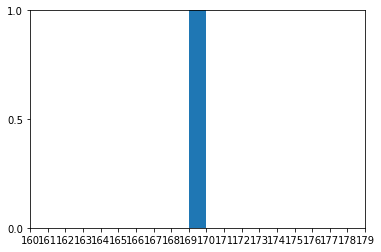

In [44]:
# Plot COM histograms
## Plot histogram of just the at threshold points
bins_threshold = np.arange(166-3,173+3,1)
# bins_threshold = np.arange(0,8,1)
plt.hist(COM_filtered,bins_threshold, density=True)
# plt.ylim([0,1.1])
plt.ylim([0,1])
# plt.yticks([0,0.50,1])
plt.yticks([0,0.50,1])
plt.xticks(np.arange(160, 180, 1))
# plt.xticks(np.arange(0, 8, 1))
# plt.savefig("figure6_somatic_hist.pdf",format="pdf", bbox_inches="tight")

## Plot real triplet data for paper

In [21]:
# Load in mat file
data = loadmat('/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src/data/triplet_data/axonal_2020-10-06-7_c244.mat') # ON AXONAL
# data = loadmat('/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src/data/triplet_data/axonal-far_2020-10-06-7_c292.mat') # OFF AXONAL
# data = loadmat('/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src/data/triplet_data/somatic_2020-10-18-5_c212.mat') # SOMATIC

# print(np.unique(data['probs'][0]))

i1_real = []
i2_real = []
i3_real = []
colors = []

for ii,amps in enumerate(data['amplitudes']):
    prob = data['probs'][0][ii]
    if prob >= 0.7 and prob <= 1:
        i2_real.append(amps[0])
        i1_real.append(amps[1])
        i3_real.append(amps[2])
        colors.append('black')


In [22]:
# Create a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=i1_real,
    y=i2_real,
    z=i3_real,
    mode='markers',
    marker=dict(
        size=5,
        color=colors,
        opacity=0.5
        )
    )
])

# Set the axis range
fig.update_layout(scene=dict(
    xaxis=dict(range=[-2.5, 2.5]),
    yaxis=dict(range=[-2.5, 2.5]),
    zaxis=dict(range=[-2.5, 2.5]),
    aspectmode='cube'
))

# Label x,y,z axes
fig.update_layout(scene=dict(
    xaxis_title='I1',
    yaxis_title='I2',
    zaxis_title='I3'
))

# Update layout to make the axes less visible
fig.update_layout(scene=dict(
    xaxis=dict(
        showgrid=False,
        showline=False,
        showticklabels=True,
        gridcolor='rgba(0,0,0,0)',
        linecolor='rgba(0,0,0,0)',
        tickcolor='rgba(0,0,0,0)'
    ),
    yaxis=dict(
        showgrid=False,
        showline=False,
        showticklabels=True,
        gridcolor='rgba(0,0,0,0)',
        linecolor='rgba(0,0,0,0)',
        tickcolor='rgba(0,0,0,0)'
    ),
    zaxis=dict(
        showgrid=False,
        showline=False,
        showticklabels=True,
        gridcolor='rgba(0,0,0,0)',
        linecolor='rgba(0,0,0,0)',
        tickcolor='rgba(0,0,0,0)'
    )
))
# Only plot ticks at -2, 0, +2
fig.update_layout(scene=dict(
    xaxis=dict(tickvals=[-2,0,2]),
    yaxis=dict(tickvals=[-2,0,2]),
    zaxis=dict(tickvals=[-2,0,2])
))


fig.show()

# Save a specific orientation as a PDF 
# select the orientation
fig.update_layout(scene_camera=dict(eye=dict(x=-2, y=2, z=.5)))
# fig.update_layout(scene_camera=dict(eye=dict(x=2, y=-2, z=.5)))
fig.write_image("fig6_real_onAxonal.pdf")

NameError: name 'go' is not defined

## Similar to radial sampling, but sample on plane

In [23]:
def define_plane_and_sample(points):
    # Unpack points
    P1, P2, P3, P4 = points

    # Define vectors
    v1 = P2 - P1
    v2 = P3 - P1

    # Normal vector of the plane
    n = np.cross(v1, v2)
    n = n / np.linalg.norm(n)  # Normalize

    print(n)
    print(-1*n)

    # Define the plane equation n . (P - P1) = 0, which simplifies to Ax + By + Cz + D = 0
    A, B, C = n
    D = -np.dot(n, P1)

    # Define the parameterization of the plane
    def parameterize(s, t):
        return P1 + s * v1 + t * v2

    # Sample points evenly
    s_values = np.linspace(0, 1, 30)
    t_values = np.linspace(0, 1, 30)
    sampled_points = [parameterize(s, t) for s in s_values for t in t_values]

    # Create normal vectors for each sampled point
    normals = [n for _ in sampled_points]

    return np.array(sampled_points), np.array(normals)

# Define the four bounding points
P1 = np.array([-4, 0.5, -4])
P2 = np.array([-4, 0.5, 4])
P3 = np.array([4, -0.5, -4])
P4 = np.array([4, -0.5, 4])
points = [P1, P2, P3, P4]

# Get the sampled points
samples, normals = define_plane_and_sample(points)

# Extract coordinates for Plotly
x_samples = samples[:, 0]
y_samples = samples[:, 1]
z_samples = samples[:, 2]

# Extract coordinates for Plotly
x_samples_1 = samples[:, 0] + -1*normals[:,0]*2
y_samples_1 = samples[:, 1] + -1*normals[:,1]*2
z_samples_1 = samples[:, 2] + -1*normals[:,2]*2



# Create a 3D scatter plot with the original filtered points and the new samples
fig = go.Figure()

# Add the original scatter plot
fig.add_trace(go.Scatter3d(
    x=i1_filtered,
    y=i2_filtered,
    z=i3_filtered,
    mode='markers',
    marker=dict(
        size=5,
        color=COM_filtered,
        colorscale='RdBu',
        cmin=166,
        cmax=172,
        colorbar=dict(
            title='Color Scale',
            tickvals=[166, 167, 168, 169, 170, 171, 172],
            ticks='outside'
        )
    )
))

# Add the new sampled points
fig.add_trace(go.Scatter3d(
    x=x_samples,
    y=y_samples,
    z=z_samples,
    mode='markers',
    marker=dict(
        size=5,
        color='blue',
        opacity=0.8
    ),
    name='Sampled Points'
))

# Add the new sampled points
fig.add_trace(go.Scatter3d(
    x=x_samples_1,
    y=y_samples_1,
    z=z_samples_1,
    mode='markers',
    marker=dict(
        size=5,
        color='red',
        opacity=0.8
    ),
    name='Sampled Points'
))


# Set the axis range
fig.update_layout(scene=dict(
    xaxis=dict(range=[-4, 4]),
    yaxis=dict(range=[-4, 4]),
    zaxis=dict(range=[-4, 4]),
    aspectmode='cube'
))

fig.show()

[ 0.12403473  0.99227788 -0.        ]
[-0.12403473 -0.99227788  0.        ]


NameError: name 'go' is not defined

In [750]:
samples[0:30]

array([[-4.        ,  0.5       , -4.        ],
       [-3.72413793,  0.46551724, -4.        ],
       [-3.44827586,  0.43103448, -4.        ],
       [-3.17241379,  0.39655172, -4.        ],
       [-2.89655172,  0.36206897, -4.        ],
       [-2.62068966,  0.32758621, -4.        ],
       [-2.34482759,  0.29310345, -4.        ],
       [-2.06896552,  0.25862069, -4.        ],
       [-1.79310345,  0.22413793, -4.        ],
       [-1.51724138,  0.18965517, -4.        ],
       [-1.24137931,  0.15517241, -4.        ],
       [-0.96551724,  0.12068966, -4.        ],
       [-0.68965517,  0.0862069 , -4.        ],
       [-0.4137931 ,  0.05172414, -4.        ],
       [-0.13793103,  0.01724138, -4.        ],
       [ 0.13793103, -0.01724138, -4.        ],
       [ 0.4137931 , -0.05172414, -4.        ],
       [ 0.68965517, -0.0862069 , -4.        ],
       [ 0.96551724, -0.12068966, -4.        ],
       [ 1.24137931, -0.15517241, -4.        ],
       [ 1.51724138, -0.18965517, -4.   

## Radial sampling 

In [751]:
import numpy as np

# Endpoints of the line
# r0 = np.array([-4, 4, 0])
# r1 = np.array([4, -4, 0])
r0 = np.array([7.5, -9.5, 7])
r1 = np.array([-7.5, 9.5, -7])

# Direction vector
d = r1 - r0

# Normalize direction vector
d_unit = d / np.linalg.norm(d)

# Find two perpendicular vectors using Gram-Schmidt process
u = np.cross(d_unit, np.array([1, 0, 0]))
if np.linalg.norm(u) == 0:  # if d_unit is parallel to [1, 0, 0]
    u = np.cross(d_unit, np.array([0, 1, 0]))
u = u / np.linalg.norm(u)
v = np.cross(d_unit, u)

# Parameters for sampling
# num_samples_along_line = 30
# num_radial_samples = 30
# radius = 0.2
num_samples_along_line = 50
num_radial_samples = 20
radius = 0.2

# Generate samples
samples = []
t_values = np.linspace(0, 1, num_samples_along_line)
theta_values = np.linspace(0, 2 * np.pi, num_radial_samples)

for t in t_values:
    r_t = (1 - t) * r0 + t * r1
    for theta in theta_values:
        p = r_t + radius * (np.cos(theta) * u + np.sin(theta) * v)
        samples.append(p)

samples = np.array(samples)

# Extract coordinates for Plotly
x_samples = samples[:, 0]
y_samples = samples[:, 1]
z_samples = samples[:, 2]

# Create a 3D scatter plot with the original filtered points and the new samples
fig = go.Figure()

# Add the original scatter plot
fig.add_trace(go.Scatter3d(
    x=i1_filtered,
    y=i2_filtered,
    z=i3_filtered,
    mode='markers',
    marker=dict(
        size=5,
        color=COM_filtered,
        colorscale='RdBu',
        cmin=166,
        cmax=172,
        colorbar=dict(
            title='Color Scale',
            tickvals=[166, 167, 168, 169, 170, 171, 172],
            ticks='outside'
        )
    )
))

# Add the new sampled points
fig.add_trace(go.Scatter3d(
    x=x_samples,
    y=y_samples,
    z=z_samples,
    mode='markers',
    marker=dict(
        size=5,
        color='blue',
        opacity=0.8
    ),
    name='Sampled Points'
))

# Set the axis range
fig.update_layout(scene=dict(
    xaxis=dict(range=[-10, 10]),
    yaxis=dict(range=[-10, 10]),
    zaxis=dict(range=[-10, 10]),
    aspectmode='cube'
))

fig.show()

In [752]:
print(samples)

[[ 7.5        -9.61863981  6.83898883]
 [ 7.44519303 -9.64025464  6.86837617]
 [ 7.39632524 -9.6466707   6.912027  ]
 ...
 [-7.39632524  9.45942375 -7.16614786]
 [-7.44519303  9.41583149 -7.17295045]
 [-7.5         9.38136019 -7.16101117]]


## Calculate bi-electtrode rotations around the cell positioning

In [482]:
# Define rotation matrix for a line segment about the origin 
rot_deg = 75
theta = np.deg2rad(rot_deg) 
rot_mat = np.array([[np.cos(theta), -1*np.sin(theta)],
                    [np.sin(theta), np.cos(theta)]])

point1 = np.array([-15, 0])
point2 = np.array([15, 0])


In [483]:
point1_rot = np.round(np.matmul(point1, rot_mat),2)
point2_rot = np.round(np.matmul(point2, rot_mat),2)

print(point1_rot)
print(point2_rot)

[-3.88 14.49]
[  3.88 -14.49]


In [484]:
elec1 = [-1015+point1_rot[0],0+point1_rot[1]]
elec2 = [-1015+point2_rot[0],0+point2_rot[1]]

print(elec1)
print(elec2)

[-1018.88, 14.49]
[-1011.12, -14.49]
